In [138]:
from biolearn.data_library import DataLibrary, GeoData
from biolearn.model_gallery import ModelGallery
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from biolearn.mortality import run_predictions, calculate_mortality_hazard_ratios
from biolearn.load import load_nhanes
year = 2010
df = load_nhanes(year)
df["years_until_death"] = df["months_until_death"] / 12

# Load clocks/models
Horvathv1 = ModelGallery().get("Horvathv1")
Hannum = ModelGallery().get("Hannum")
# Load dataframe
data = DataLibrary().get("GSE110554").load()

prediction = Hannum.predict

# # Make dictionary for mortality
# prediction_dict = {
#     "Horvathv1": "Predicted",
#     "Hannum": "Predicted"
# }

# predictions = run_predictions(data, prediction_dict)





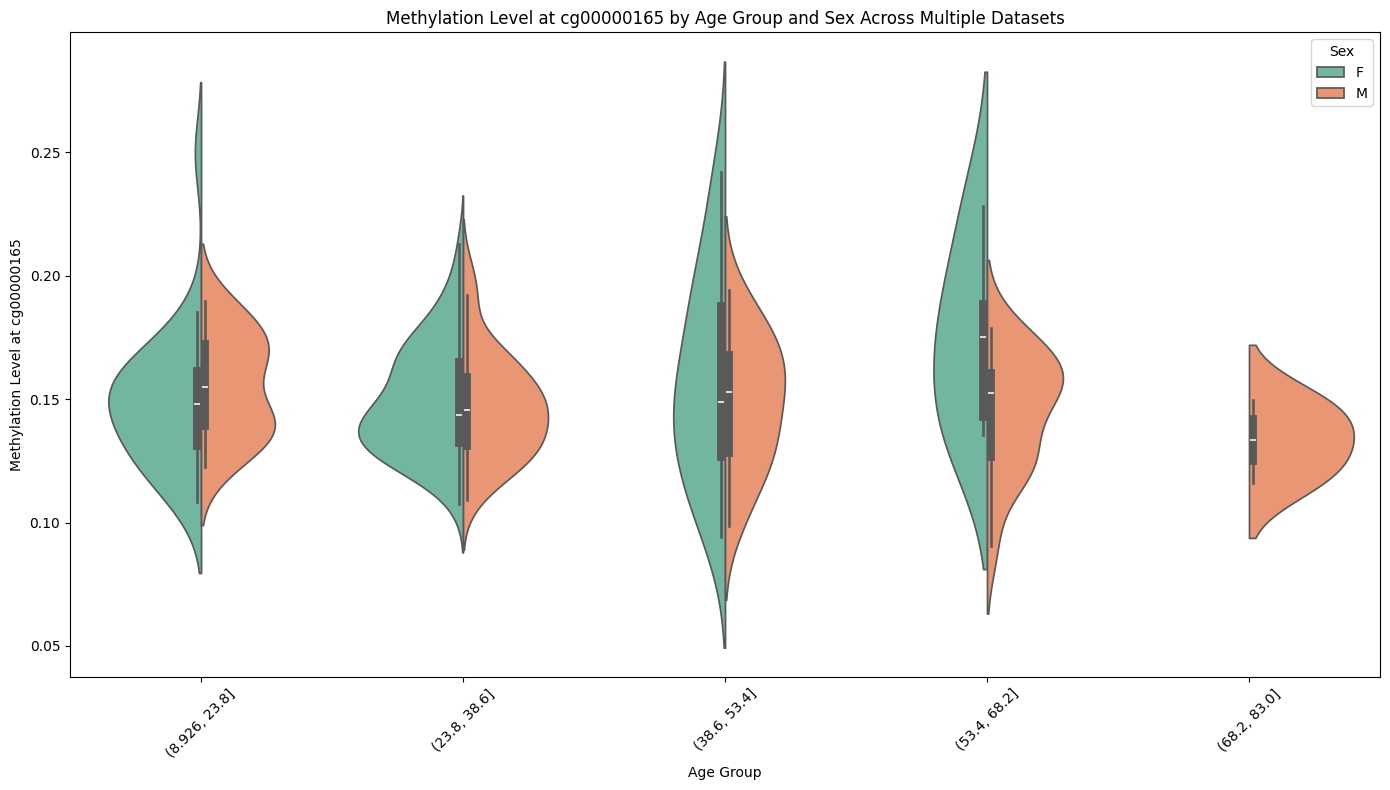

             age sex  methylation    dataset      age_group
GSM1272122  18.0   F     0.144547  Dataset 1  (8.926, 23.8]
GSM1272123  12.0   M     0.138556  Dataset 1  (8.926, 23.8]
GSM1272124  13.0   M     0.168532  Dataset 1  (8.926, 23.8]
GSM1272125  24.0   F     0.149443  Dataset 1   (23.8, 38.6]
GSM1272126  33.0   F     0.138960  Dataset 1   (23.8, 38.6]
...          ...  ..          ...        ...            ...
GSM1009890  27.0   F     0.174138  Dataset 3   (23.8, 38.6]
GSM1009891  29.0   F     0.149007  Dataset 3   (23.8, 38.6]
GSM1009892  29.0   F     0.152924  Dataset 3   (23.8, 38.6]
GSM1009893  29.0   F     0.129513  Dataset 3   (23.8, 38.6]
GSM1009894  23.0   F     0.147505  Dataset 3  (8.926, 23.8]

[217 rows x 5 columns]
       age_group  male_mean  female_mean  male_median  female_median  \
0  (8.926, 23.8]   0.155230     0.148628     0.154726       0.147844   
1   (23.8, 38.6]   0.146817     0.149233     0.145642       0.143593   
2   (38.6, 53.4]   0.148503     0.157985

In [183]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


def plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5):
    """
    Visualizes methylation levels at a specific CpG site by age group and sex, across multiple datasets.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' and 'sex' columns.
    - cpg_site (str): CpG site ID to visualize.
    - age_bins (int): Number of age bins for grouping, default is 5.

    Output:
    - Displays a combined violin plot of methylation levels for the specified CpG site, grouped by age and split by sex across datasets.
    """

    # Initialize a list to collect methylation data from all datasets
    combined_data = []

    # Define a mapping for sex annotations
    sex_mapping = {1: 'M', 2: 'F', '1': 'M', '2': 'F', 'M': 'M', 'F': 'F', 'Male': 'M', 'Female': 'F'}

    for i, (data_dnam, data_meta) in enumerate(datasets):
        # Check if CpG site is in current dataset
        if cpg_site not in data_dnam.index:
            print(f"Warning: CpG site '{cpg_site}' not found in dataset {i + 1}. Skipping this dataset.")
            continue
        
        # Extract methylation data for the specific CpG site
        methylation_data = data_dnam.loc[cpg_site]
        
        # Align metadata and methylation data by sample ID
        valid_samples = data_meta.index.intersection(methylation_data.index)
        plot_data = data_meta.loc[valid_samples, ['age', 'sex']].copy()
        plot_data['methylation'] = methylation_data[valid_samples]

        # Apply the sex mapping to standardize annotations
        plot_data['sex'] = plot_data['sex'].replace(sex_mapping)

        

        # # Add dataset identifier for tracking
        plot_data['dataset'] = f'Dataset {i + 1}'
        

        # Append to combined data list
        combined_data.append(plot_data)

    # Concatenate all datasets into a single DataFrame
    combined_data = pd.concat(combined_data, axis=0)

    # Drop rows with NaN values in age or methylation columns
    combined_data = combined_data.dropna(subset=['age', 'methylation'])
    
    # Create age groups for consistent grouping across datasets
    combined_data['age_group'] = pd.cut(combined_data['age'], bins=age_bins)


    # Plot
    plt.figure(figsize=(14, 8))
    
    sns.violinplot(
        x='age_group', 
        y='methylation', 
        hue='sex', 
        data=combined_data, 
        split=True, 
        palette="Set2"
    )
    # Initialize a list to store statistics
    stats_summary = []

    # Group by age_group to compute statistics for each age range
    age_groups = combined_data['age_group'].unique()
    for age_group in age_groups:
        group_data = combined_data[combined_data['age_group'] == age_group]
        
        # Separate data by sex within the age group
        male_data = group_data[group_data['sex'] == 'M']['methylation']
        female_data = group_data[group_data['sex'] == 'F']['methylation']
        
        # Calculate statistics
        stats_row = {
            'age_group': age_group,
            'male_mean': male_data.mean(),
            'female_mean': female_data.mean(),
            'male_median': male_data.median(),
            'female_median': female_data.median(),
            'male_std': male_data.std(),
            'female_std': female_data.std(),
            'male_count': male_data.count(),
            'female_count': female_data.count()
        }

        # Perform t-test if both groups have more than 1 sample
        # T-test for Group Differences: A t-test is performed between male and female groups in each age group to assess if there are statistically significant differences. The function also includes significance stars based on the p-value: * for p < 0.05, ** for p < 0.01, and *** for p < 0.001.
        if len(male_data) > 1 and len(female_data) > 1:
            t_stat, p_val = stats.ttest_ind(male_data, female_data, nan_policy='omit')
            stats_row['p_value'] = p_val
            # Add significance stars based on p-value
            stats_row['significance'] = ''
            if p_val < 0.05:
                stats_row['significance'] = '*'
            if p_val < 0.01:
                stats_row['significance'] = '**'
            if p_val < 0.001:
                stats_row['significance'] = '***'
        else:
            stats_row['p_value'] = None
            stats_row['significance'] = ''

        # Append statistics for the current age group
        stats_summary.append(stats_row)

    # Convert the summary list to a DataFrame for easy viewing
    stats_df = pd.DataFrame(stats_summary)

    
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex Across Multiple Datasets')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.legend(title="Sex")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(combined_data)
    print(stats_df)

from biolearn.data_library import DataLibrary, GeoData
from biolearn.model_gallery import ModelGallery

data1 = DataLibrary().get("GSE52588").load()
data2 = DataLibrary().get("GSE110554").load()
data3 = DataLibrary().get("GSE41169").load()



# Make list of tuples
datasets = [(data1.dnam, data1.metadata), (data2.dnam, data2.metadata), (data3.dnam, data3.metadata)]
cpg_site = "cg00000165"

plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5)
# data2.dnam
# data1.dnam



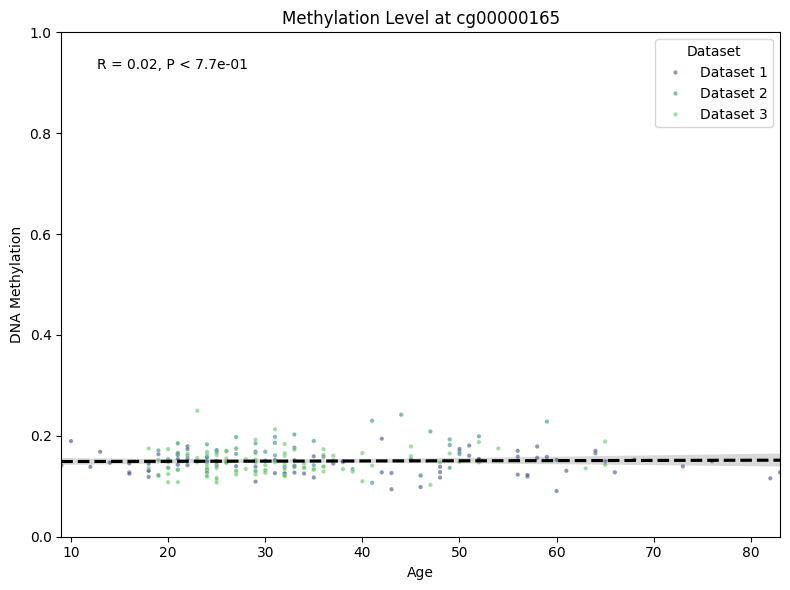

             age  methylation    dataset
GSM1272122  18.0     0.144547  Dataset 1
GSM1272123  12.0     0.138556  Dataset 1
GSM1272124  13.0     0.168532  Dataset 1
GSM1272125  24.0     0.149443  Dataset 1
GSM1272126  33.0     0.138960  Dataset 1
...          ...          ...        ...
GSM1009890  27.0     0.174138  Dataset 3
GSM1009891  29.0     0.149007  Dataset 3
GSM1009892  29.0     0.152924  Dataset 3
GSM1009893  29.0     0.129513  Dataset 3
GSM1009894  23.0     0.147505  Dataset 3

[217 rows x 3 columns]


In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def plot_methylation_vs_age(datasets, cpg_site):
    """
    Plots the DNA methylation level of a specific CpG site against age across multiple datasets,
    with a regression line, correlation coefficient, and p-value.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' column.
    - cpg_site (str): CpG site ID to visualize.

    Output:
    - Displays a scatter plot of methylation levels vs age for the specified CpG site,
      with a regression line, R, and p-value.
    """

    # Initialize a list to collect methylation data and age from all datasets
    combined_data = []

    for i, (data_dnam, data_meta) in enumerate(datasets):
        # Check if CpG site is in current dataset
        if cpg_site not in data_dnam.index:
            print(f"Warning: CpG site '{cpg_site}' not found in dataset {i + 1}. Skipping this dataset.")
            continue
        
        # Extract methylation data for the specific CpG site
        methylation_data = data_dnam.loc[cpg_site]
        
        # Align metadata and methylation data by sample ID
        valid_samples = data_meta.index.intersection(methylation_data.index)
        plot_data = data_meta.loc[valid_samples, ['age']].copy()
        plot_data['methylation'] = methylation_data[valid_samples]
        
        # Add dataset identifier for color coding
        plot_data['dataset'] = f'Dataset {i + 1}'
        
        # Append to combined data list
        combined_data.append(plot_data)

    # Concatenate all datasets into a single DataFrame
    combined_data = pd.concat(combined_data, axis=0)

    # Drop rows with NaN values in age or methylation columns
    combined_data = combined_data.dropna(subset=['age', 'methylation'])

    # Calculate correlation coefficient (R) and p-value
    r_value, p_value = pearsonr(combined_data['age'], combined_data['methylation'])

    # Plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='age', y='methylation', hue='dataset', data=combined_data, palette="viridis", alpha=0.6, s=10)
    sns.regplot(x='age', y='methylation', data=combined_data, scatter=False, color='black', line_kws={"linestyle": "--"})

    # Annotate with correlation coefficient and p-value
    plt.text(0.05, 0.95, f"R = {r_value:.2f}, P < {p_value:.1e}", transform=plt.gca().transAxes, ha='left', va='top')

    # Add title and labels
    plt.title(f"Methylation Level at {cpg_site}")
    plt.xlabel("Age")
    plt.ylabel("DNA Methylation")
    plt.ylim(0, 1)  # Assuming methylation values are between 0 and 1
    plt.xlim(combined_data['age'].min(), combined_data['age'].max())
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.show()
    print(combined_data)

    from biolearn.data_library import DataLibrary, GeoData
from biolearn.model_gallery import ModelGallery

data1 = DataLibrary().get("GSE52588").load()
data2 = DataLibrary().get("GSE110554").load()
data3 = DataLibrary().get("GSE41169").load()



# Make list of tuples
datasets = [(data1.dnam, data1.metadata), (data2.dnam, data2.metadata), (data3.dnam, data3.metadata)]
cpg_site = "cg00000165"

plot_methylation_vs_age(datasets, cpg_site)
# data2.dnam


In [181]:
# Backup for violin plot

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


def plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5):
    """
    Visualizes methylation levels at a specific CpG site by age group and sex, across multiple datasets.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' and 'sex' columns.
    - cpg_site (str): CpG site ID to visualize.
    - age_bins (int): Number of age bins for grouping, default is 5.

    Output:
    - Displays a combined violin plot of methylation levels for the specified CpG site, grouped by age and split by sex across datasets.
    """

    # Initialize a list to collect methylation data from all datasets
    combined_data = []

    # Define a mapping for sex annotations
    sex_mapping = {1: 'M', 2: 'F', '1': 'M', '2': 'F', 'M': 'M', 'F': 'F', 'Male': 'M', 'Female': 'F'}

    for i, (data_dnam, data_meta) in enumerate(datasets):
        # Check if CpG site is in current dataset
        if cpg_site not in data_dnam.index:
            print(f"Warning: CpG site '{cpg_site}' not found in dataset {i + 1}. Skipping this dataset.")
            continue
        
        # Extract methylation data for the specific CpG site
        methylation_data = data_dnam.loc[cpg_site]
        
        # Align metadata and methylation data by sample ID
        valid_samples = data_meta.index.intersection(methylation_data.index)
        plot_data = data_meta.loc[valid_samples, ['age', 'sex']].copy()
        plot_data['methylation'] = methylation_data[valid_samples]

        # Apply the sex mapping to standardize annotations
        plot_data['sex'] = plot_data['sex'].replace(sex_mapping)

        

        # # Add dataset identifier for tracking
        plot_data['dataset'] = f'Dataset {i + 1}'
        

        # Append to combined data list
        combined_data.append(plot_data)

    # Concatenate all datasets into a single DataFrame
    combined_data = pd.concat(combined_data, axis=0)
    
    # Create age groups for consistent grouping across datasets
    combined_data['age_group'] = pd.cut(combined_data['age'], bins=age_bins)


    # Plot
    plt.figure(figsize=(14, 8))
    
    sns.violinplot(
        x='age_group', 
        y='methylation', 
        hue='sex', 
        data=combined_data, 
        split=True, 
        palette="Set2"
    )
    # Initialize a list to store statistics
    stats_summary = []

    # Group by age_group to compute statistics for each age range
    age_groups = combined_data['age_group'].unique()
    for age_group in age_groups:
        group_data = combined_data[combined_data['age_group'] == age_group]
        
        # Separate data by sex within the age group
        male_data = group_data[group_data['sex'] == 'M']['methylation']
        female_data = group_data[group_data['sex'] == 'F']['methylation']
        
        # Calculate statistics
        stats_row = {
            'age_group': age_group,
            'male_mean': male_data.mean(),
            'female_mean': female_data.mean(),
            'male_median': male_data.median(),
            'female_median': female_data.median(),
            'male_std': male_data.std(),
            'female_std': female_data.std(),
            'male_count': male_data.count(),
            'female_count': female_data.count()
        }

        # Perform t-test if both groups have more than 1 sample
        # T-test for Group Differences: A t-test is performed between male and female groups in each age group to assess if there are statistically significant differences. The function also includes significance stars based on the p-value: * for p < 0.05, ** for p < 0.01, and *** for p < 0.001.
        if len(male_data) > 1 and len(female_data) > 1:
            t_stat, p_val = stats.ttest_ind(male_data, female_data, nan_policy='omit')
            stats_row['p_value'] = p_val
            # Add significance stars based on p-value
            stats_row['significance'] = ''
            if p_val < 0.05:
                stats_row['significance'] = '*'
            if p_val < 0.01:
                stats_row['significance'] = '**'
            if p_val < 0.001:
                stats_row['significance'] = '***'
        else:
            stats_row['p_value'] = None
            stats_row['significance'] = ''

        # Append statistics for the current age group
        stats_summary.append(stats_row)

    # Convert the summary list to a DataFrame for easy viewing
    stats_df = pd.DataFrame(stats_summary)

    
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex Across Multiple Datasets')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.legend(title="Sex")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(combined_data)
    print(stats_df)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def plot_cell_type_aging_trajectory(data, age_column='Age', deconvolute_method=DeconvoluteBloodEPIC, cell_types=None, age_range=None):
    """
    Plot cell type proportion changes over age using deconvolution from DNA methylation data.
    
    Parameters:
        data (pd.DataFrame): The dataset containing DNA methylation data with age and sample IDs.
        age_column (str): The name of the column containing chronological age of individuals.
        deconvolute_method: The deconvolution method used for estimating cell type proportions.
        cell_types (list): List of cell types to include in the plot (default: None, which plots all available).
        age_range (tuple): The range of ages to include in the plot (e.g., (20, 80)). If None, use the full range.
    
    Returns:
        plt.Figure: A plot showing the trajectory of cell type proportions across the age range.
    """
    # Perform deconvolution to estimate cell type proportions
    decon_results = deconvolute_method(data)
    
    # Convert deconvolution results into a DataFrame for easy plotting
    decon_df = pd.DataFrame(decon_results, columns=['Neutrophils', 'Monocytes', 'NK_Cells', 'B_Cells', 'CD4_T_Cells', 'CD8_T_Cells'])
    decon_df[age_column] = data[age_column]
    
    # Filter by the specified age range, if provided
    if age_range:
        decon_df = decon_df[(decon_df[age_column] >= age_range[0]) & (decon_df[age_column] <= age_range[1])]
    
    # If specific cell types are provided, filter the DataFrame to include only those
    if cell_types:
        decon_df = decon_df[cell_types + [age_column]]
    
    # Melt the DataFrame for easier plotting with seaborn
    melted_df = pd.melt(decon_df, id_vars=[age_column], var_name='Cell_Type', value_name='Proportion')
    
    # Plot the cell type trajectories
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=melted_df, x=age_column, y='Proportion', hue='Cell_Type', marker="o")
    
    # Add labels and title
    plt.title('Cell Type Proportion Changes Across Age')
    plt.xlabel('Age (Years)')
    plt.ylabel('Proportion of Cell Types')
    plt.legend(title='Cell Types')
    
    plt.grid(True)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Example usage
# Assuming we have a DataFrame `methylation_data` with DNA methylation data and an 'Age' column
# plot_cell_type_aging_trajectory(methylation_data)


In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

def plot_pca_methylation(datasets, color_by="age"):
    """
    Perform PCA on the methylation data to reduce dimensionality and plot the first two principal components.
    
    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' or 'dataset' columns.
    - color_by (str): Determines how the points are colored in the plot. Options are "age" or "dataset".
    
    Output:
    - Displays a PCA plot of the first two principal components of the methylation data, colored by the specified attribute.
    """
    
    # Initialize lists to collect methylation data and metadata
    combined_data = []
    combined_meta = []

    for i, (data_dnam, data_meta) in enumerate(datasets):
        # Standardize and transpose methylation data (samples as rows, CpG sites as columns)
        methylation_data = data_dnam.T
        methylation_data_std = pd.DataFrame(StandardScaler().fit_transform(methylation_data), 
                                            columns=methylation_data.columns, index=methylation_data.index)
        
        # Add metadata, including dataset identifier
        data_meta = data_meta.copy()
        data_meta['dataset'] = f"Dataset {i + 1}"
        
        # Align and collect the data
        combined_data.append(methylation_data_std)
        combined_meta.append(data_meta)

    # Concatenate all datasets into single DataFrames
    combined_data = pd.concat(combined_data, axis=0)
    combined_meta = pd.concat(combined_meta, axis=0)

    # Perform PCA
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(combined_data)
    pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"], index=combined_data.index)

    # Merge PCA results with metadata
    pca_df = pd.concat([pca_df, combined_meta], axis=1)

    # Plot
    plt.figure(figsize=(10, 8))
    
    if color_by == "age":
        # Use a colormap for continuous variable (age)
        scatter = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["age"], cmap="viridis", alpha=0.7, s=50)
        plt.colorbar(scatter, label="Age")
    elif color_by == "dataset":
        sns.scatterplot(x="PC1", y="PC2", hue="dataset", data=pca_df, palette="Set2", s=50, alpha=0.7)
        plt.legend(title="Dataset")

    # Add labels and title
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)")
    plt.title("PCA of Methylation Data")
    plt.tight_layout()
    plt.show()

# Assume data1 and data2 are datasets loaded from Biolearn
from biolearn.data_library import DataLibrary

data1 = DataLibrary().get("GSE112618").load()
data2 = DataLibrary().get("GSE110554").load()

datasets = [(data1.dnam, data1.metadata), (data2.dnam, data2.metadata)]

# Call the function to plot PCA, color-coded by age
plot_pca_methylation(datasets, color_by="age")

# Or call the function to plot PCA, color-coded by dataset
plot_pca_methylation(datasets, color_by="dataset")

In [146]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_top_cpg_sites_by_loadings(data_dnam, top_n=10):
    """
    Perform PCA on the methylation data and retrieve the CpG sites with the highest loadings
    for the first principal component.

    Parameters:
    - data_dnam (DataFrame): DNAm data with CpG sites as rows and samples as columns.
    - top_n (int): Number of top CpG sites to retrieve based on absolute loadings.

    Output:
    - DataFrame showing the CpG sites with the highest loadings for PC1 and PC2.
    """
    # Standardize the data (samples as rows, CpG sites as columns)
    data_dnam_std = StandardScaler().fit_transform(data_dnam.T)
    
    # Perform PCA
    pca = PCA(n_components=2)
    pca.fit(data_dnam_std)

    # Get loadings for PC1 and PC2
    loadings = pd.DataFrame(pca.components_.T, index=data_dnam.index, columns=['PC1', 'PC2'])

    # Get the top CpG sites for PC1 and PC2 by absolute loading values
    top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(top_n)
    top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(top_n)

    # Create a DataFrame to display top CpG sites for each component
    top_cpg_sites = pd.DataFrame({
        'PC1_CpG': top_pc1.index,
        'PC1_Loading': top_pc1.values,
        'PC2_CpG': top_pc2.index,
        'PC2_Loading': top_pc2.values
    })

    return top_cpg_sites

# Example usage:
# Load datasets using Biolearn
from biolearn.data_library import DataLibrary

data1 = DataLibrary().get("GSE112618").load()
data2 = DataLibrary().get("GSE110554").load()

# Concatenate DNAm data from multiple datasets
datasets = [data1.dnam, data2.dnam]
data_dnam_combined = pd.concat(datasets, axis=1)

# Get top CpG sites with highest loadings for PC1 and PC2
top_cpg_sites = get_top_cpg_sites_by_loadings(data_dnam_combined, top_n=10)
print(top_cpg_sites)

      PC1_CpG  PC1_Loading     PC2_CpG  PC2_Loading
0  cg20271081     0.002177  cg21304833     0.002372
1  cg11257462     0.002172  cg10610704     0.002355
2  cg07954456     0.002170  cg25960382     0.002347
3  cg15451965     0.002168  cg06823354     0.002346
4  cg00786237     0.002167  cg22040823     0.002341
5  cg03290281     0.002166  cg08401219     0.002336
6  cg16386947     0.002165  cg08743341     0.002335
7  cg03512872     0.002161  cg15059222     0.002334
8  cg14996185     0.002161  cg25160116     0.002330
9  cg00137860     0.002160  cg08761844     0.002328


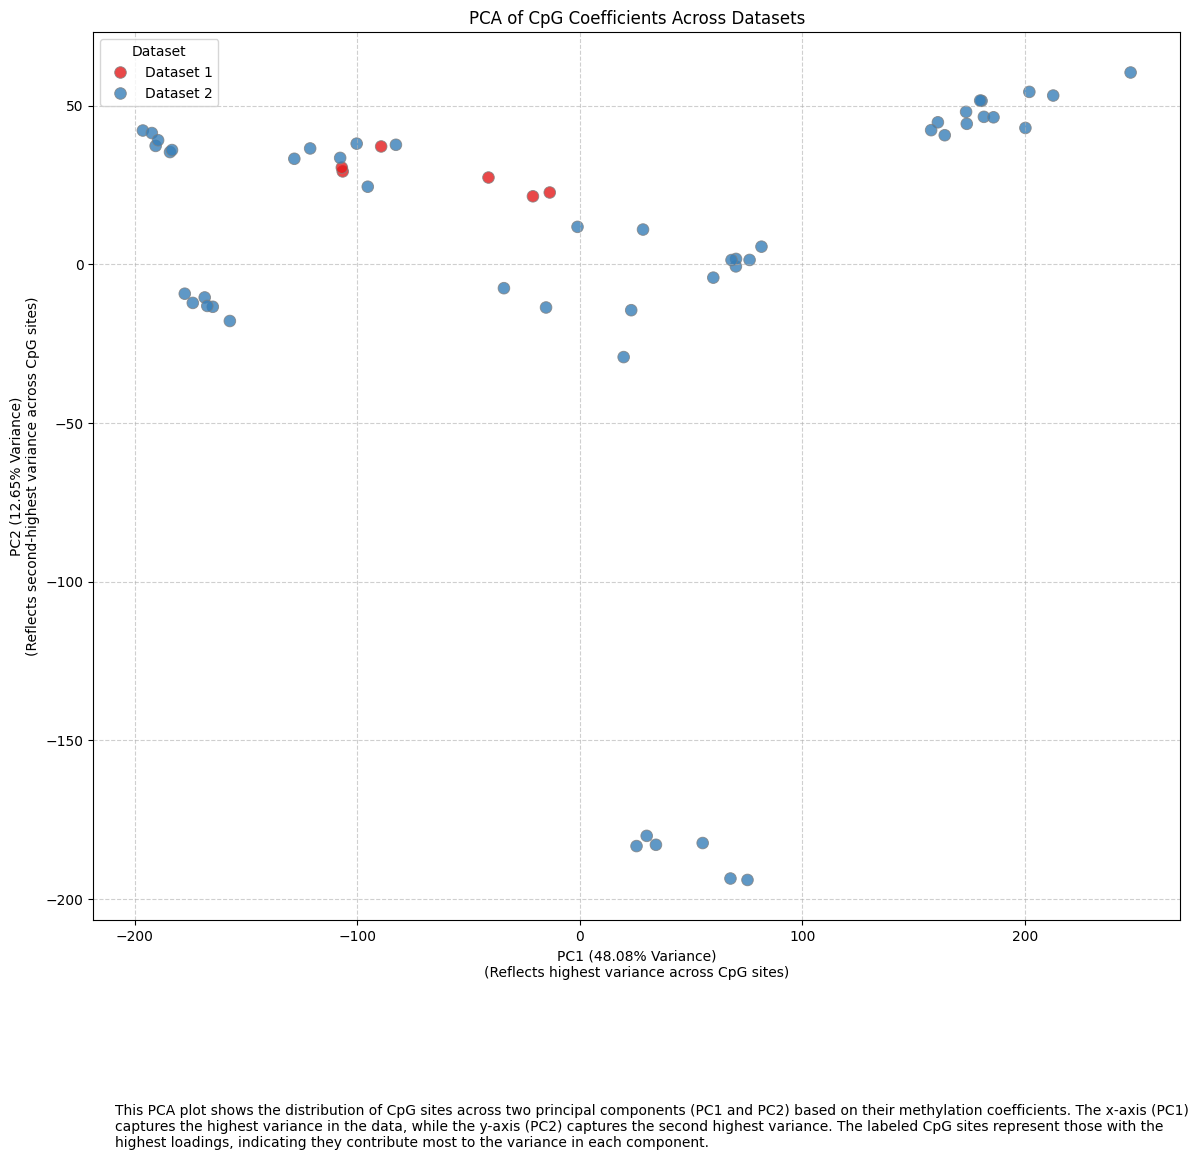

In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca_cpg_coefficients_by_dataset(datasets, top_n=5):
    """
    Perform PCA on the CpG coefficients across datasets and plot the first two principal components
    with color-coding by dataset and labeled high-loading CpG sites.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing dataset identifier.
    - top_n (int): Number of top CpG sites to label based on their loadings in PC1 and PC2.

    Output:
    - Displays a PCA plot of the first two principal components for CpG sites, with color-coding by dataset.
    """
    
    # Extract and concatenate CpG data from multiple datasets (CpG sites as rows, samples as columns)
    combined_dnam = pd.concat([data_dnam for data_dnam, _ in datasets], axis=1)
    
    # Standardize the CpG coefficient data to have mean 0 and standard deviation 1
    combined_dnam_std = StandardScaler().fit_transform(combined_dnam)

    # Perform PCA on CpG sites (rows) across samples
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(combined_dnam_std.T)  # Transpose to treat CpG sites as samples

    # Create a DataFrame for PCA results with PC1 and PC2 values for each CpG site
    pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"], index=combined_dnam.columns)

    # Add loadings to identify the top contributing CpG sites
    loadings = pd.DataFrame(pca.components_.T, index=combined_dnam.index, columns=['PC1_loading', 'PC2_loading'])

    # Identify top CpG sites based on loadings for PC1 and PC2
    top_pc1 = loadings['PC1_loading'].abs().sort_values(ascending=False).head(top_n)
    top_pc2 = loadings['PC2_loading'].abs().sort_values(ascending=False).head(top_n)

    # Ensure labels only include CpG sites present in both loadings and pca_df
    top_pc1 = top_pc1[top_pc1.index.isin(pca_df.index)]
    top_pc2 = top_pc2[top_pc2.index.isin(pca_df.index)]

    # Color-coding by dataset (dummy example, you may need to replace this with actual dataset information)
    dataset_labels = ['Dataset 1'] * len(datasets[0][0].columns) + ['Dataset 2'] * len(datasets[1][0].columns)
    pca_df['Dataset'] = dataset_labels

    # Plotting with color-coding by dataset
    plt.figure(figsize=(12, 10))
    scatter = sns.scatterplot(x="PC1", y="PC2", data=pca_df, hue="Dataset", palette="Set1", s=70, alpha=0.8, edgecolor='gray')

    # Highlight top CpG sites in PC1 and PC2 with labels
    for cpg in top_pc1.index:
        plt.text(pca_df.loc[cpg, "PC1"], pca_df.loc[cpg, "PC2"], cpg, fontsize=9, color="darkblue", ha="right")
    for cpg in top_pc2.index:
        plt.text(pca_df.loc[cpg, "PC1"], pca_df.loc[cpg, "PC2"], cpg, fontsize=9, color="darkgreen", ha="left")

    # Add grid, labels, and title with explanations
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)\n(Reflects highest variance across CpG sites)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)\n(Reflects second-highest variance across CpG sites)")
    plt.title("PCA of CpG Coefficients Across Datasets")

    # Adding legend explanation for clarity on what the plot reflects
    plt.figtext(0.1, -0.15, ("This PCA plot shows the distribution of CpG sites across two principal components (PC1 and PC2) "
                              "based on their methylation coefficients. The x-axis (PC1) captures the highest variance in the "
                              "data, while the y-axis (PC2) captures the second highest variance. The labeled CpG sites "
                              "represent those with the highest loadings, indicating they contribute most to the variance "
                              "in each component."), wrap=True, horizontalalignment='left', fontsize=10)

    plt.tight_layout()
    plt.show()

    return pca_df, loadings

# Example usage:
from biolearn.data_library import DataLibrary

data1 = DataLibrary().get("GSE112618").load()
data2 = DataLibrary().get("GSE110554").load()

datasets = [(data1.dnam, data1.metadata), (data2.dnam, data2.metadata)]

# Call the function
pca_df, loadings = plot_pca_cpg_coefficients_by_dataset(datasets, top_n=5)


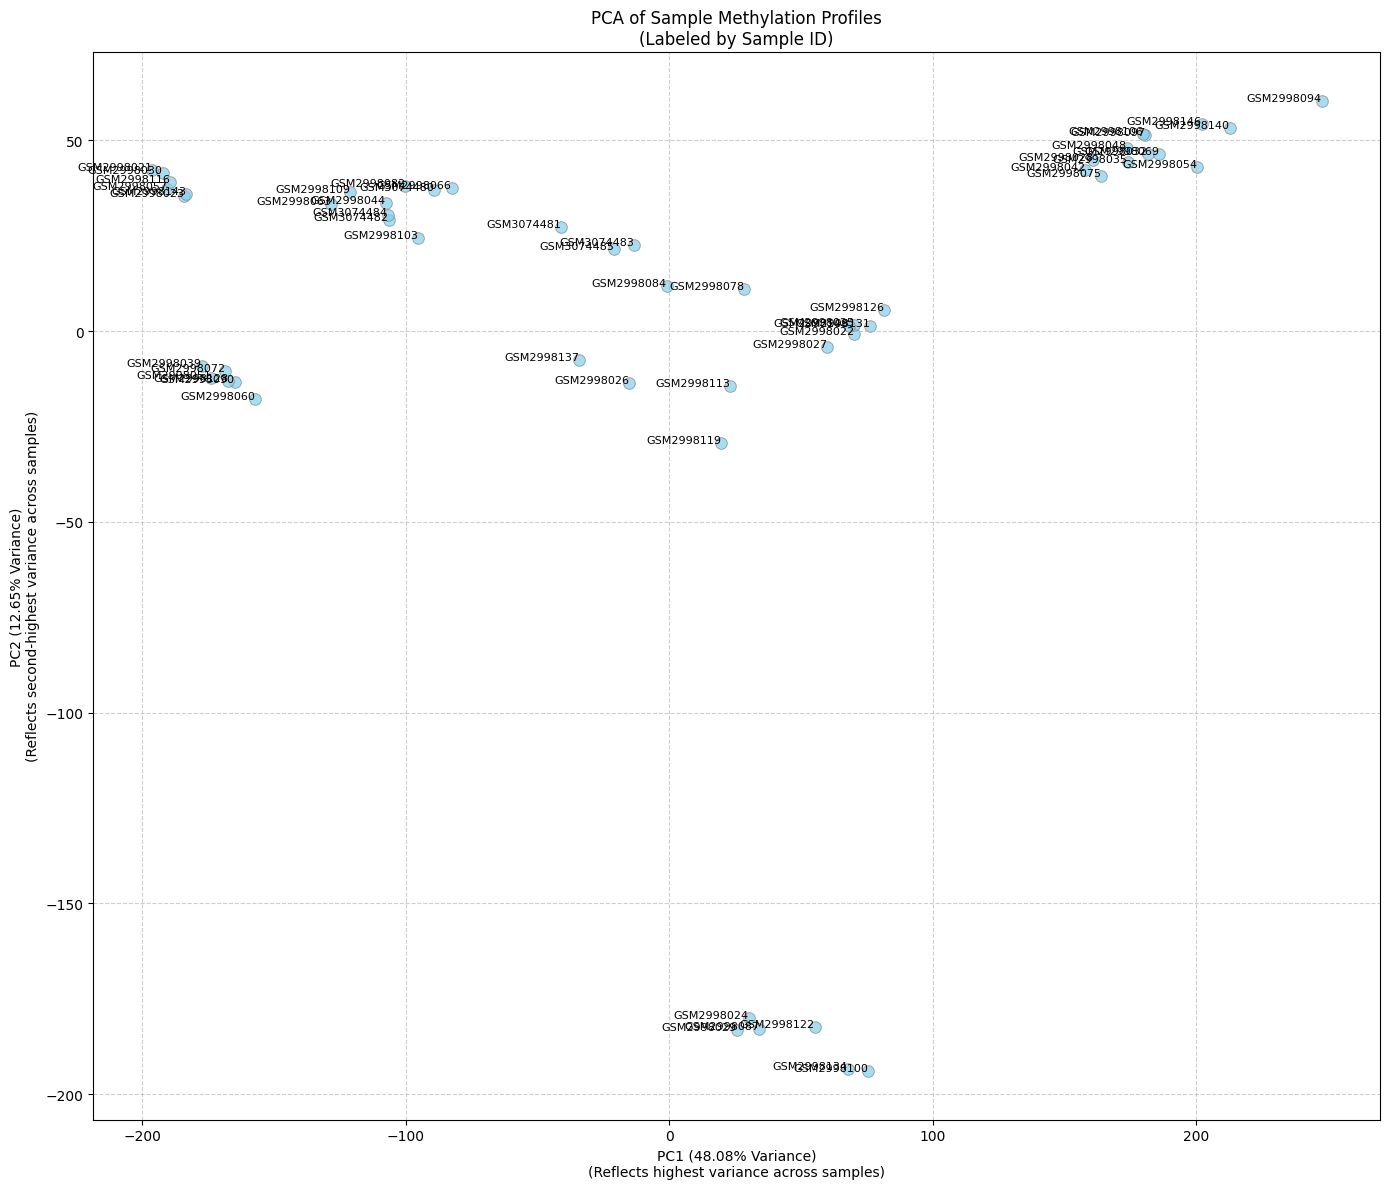

Top CpG sites for PC1:
 id
cg07110356    0.007885
cg10838410    0.007764
cg27057526    0.007684
cg22528270    0.007646
cg11327657    0.007609
Name: PC1_loading, dtype: float64

Top CpG sites for PC2:
 id
cg04828493    0.011765
cg25131632    0.011345
cg02212339    0.011266
cg07748567    0.011231
cg09558738    0.011222
Name: PC2_loading, dtype: float64


In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca_samples_with_cpg_loadings(datasets, top_n=5):
    """
    Perform PCA on the samples' methylation data and plot the first two principal components for samples.
    Additionally, examine top CpG site loadings for PC1 and PC2 to identify influential CpG sites.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing dataset identifier.
    - top_n (int): Number of top CpG sites to display based on their loadings in PC1 and PC2.

    Output:
    - Displays a PCA plot of the first two principal components for samples, and returns a DataFrame of CpG loadings.
    """
    
    # Concatenate DNAm data across datasets (CpG sites as rows, samples as columns)
    combined_dnam = pd.concat([data_dnam for data_dnam, _ in datasets], axis=1)
    
    # Standardize the CpG coefficient data
    combined_dnam_std = StandardScaler().fit_transform(combined_dnam)

    # Perform PCA on samples
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(combined_dnam_std.T)  # Transpose to treat samples as data points

    # Use sample identifiers as index for pca_df
    sample_labels = combined_dnam.columns
    pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"], index=sample_labels)

    # Plotting the PCA result for samples
    plt.figure(figsize=(14, 12))
    sns.scatterplot(x="PC1", y="PC2", data=pca_df, s=70, color='skyblue', alpha=0.7, edgecolor='gray')

    # Label each sample (if too many samples, consider commenting this out to reduce clutter)
    for sample in pca_df.index:
        plt.text(pca_df.loc[sample, "PC1"], pca_df.loc[sample, "PC2"], sample, fontsize=8, color="black", ha="right")

    # Add grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)\n(Reflects highest variance across samples)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)\n(Reflects second-highest variance across samples)")
    plt.title("PCA of Sample Methylation Profiles\n(Labeled by Sample ID)")

    plt.tight_layout()
    plt.show()

    # Extract CpG site loadings for PC1 and PC2
    loadings = pd.DataFrame(pca.components_.T, index=combined_dnam.index, columns=['PC1_loading', 'PC2_loading'])

    # Identify top CpG sites based on loadings for PC1 and PC2
    top_pc1 = loadings['PC1_loading'].abs().sort_values(ascending=False).head(top_n)
    top_pc2 = loadings['PC2_loading'].abs().sort_values(ascending=False).head(top_n)

    # Display top CpG sites with highest loadings for PC1 and PC2
    print("Top CpG sites for PC1:\n", top_pc1)
    print("\nTop CpG sites for PC2:\n", top_pc2)

    return pca_df, loadings

# Example usage:
from biolearn.data_library import DataLibrary

data1 = DataLibrary().get("GSE112618").load()
data2 = DataLibrary().get("GSE110554").load()

datasets = [(data1.dnam, data1.metadata), (data2.dnam, data2.metadata)]

# Call the function
pca_df, loadings = plot_pca_samples_with_cpg_loadings(datasets, top_n=5)


In [ ]:
from biolearn.data_library import DataLibrary, GeoData
from biolearn.model_gallery import ModelGallery
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from biolearn.mortality import run_predictions, calculate_mortality_hazard_ratios
from biolearn.load import load_nhanes
year = 2010
df = load_nhanes(year)
df["years_until_death"] = df["months_until_death"] / 12

# Load clocks/models
Horvathv1 = ModelGallery().get("Horvathv1")
Hannum = ModelGallery().get("Hannum")
# Load dataframe
data = DataLibrary().get("GSE110554").load()

prediction = Hannum.predict

# # Make dictionary for mortality
# prediction_dict = {
#     "Horvathv1": "Predicted",
#     "Hannum": "Predicted"
# }

# predictions = run_predictions(data, prediction_dict)





In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Create example DNAm data
num_samples = 20
num_cpg_sites = 10
sample_ids = [f"GSM{2998000 + i}" for i in range(num_samples)]
cpg_sites = [f"cg000000{i}" for i in range(num_cpg_sites)]

# Generate random methylation data (values between 0 and 1)
data_dnam = pd.DataFrame(
    np.random.rand(num_cpg_sites, num_samples),
    index=cpg_sites,
    columns=sample_ids
)

# Generate synthetic metadata
ages = np.random.randint(20, 80, size=num_samples)  # Random ages between 20 and 80
sexes = np.random.choice(['Male', 'Female'], size=num_samples)  # Randomly assign sex

# Create metadata DataFrame
data_meta = pd.DataFrame({
    'age': ages,
    'sex': sexes
}, index=sample_ids)


# Ensure necessary libraries are imported for plotting
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact

# Define the function for interactive selection and plotting, as detailed above
def plot_methylation_by_age_sex(data_dnam, data_meta, cpg_site):
    """
    Violin plot of DNAm levels at a specific CpG site by age group and sex.
    :param data_dnam: DataFrame with DNAm data (CpG sites as rows, sample IDs as columns).
    :param data_meta: DataFrame with metadata containing 'age' and 'sex'.
    :param cpg_site: String, the CpG site ID to plot.
    """
    if cpg_site not in data_dnam.index:
        print(f"CpG site '{cpg_site}' not found in DNAm data.")
        return

    # Extract methylation data for the specific CpG site
    methylation_data = data_dnam.loc[cpg_site]
    
    # Align metadata and methylation data
    valid_samples = data_meta.index.intersection(methylation_data.index)
    plot_data = data_meta.loc[valid_samples].copy()
    plot_data['methylation'] = methylation_data[valid_samples]
    plot_data['age_group'] = pd.cut(plot_data['age'], bins=5)  # Divide age into groups

    # Plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='age_group', y='methylation', hue='sex', data=plot_data, split=True)
    plt.title(f'Methylation Level at {cpg_site} by Age Group and Sex')
    plt.xlabel('Age Group')
    plt.ylabel(f'Methylation Level at {cpg_site}')
    plt.show()

# Interactive plot setup
def interactive_cpg_plot(data_dnam, data_meta):
    cpg_sites = data_dnam.index.tolist()
    interact(lambda cpg_site: plot_methylation_by_age_sex(data_dnam, data_meta, cpg_site), cpg_site=cpg_sites)

# Run the interactive plotting function with example data




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_methylation_by_age_sex_multiple(datasets, cpg_site, age_bins=5):
"""
    Visualizes methylation levels at a specific CpG site by age group and sex, across multiple datasets.

    Parameters:
    - datasets (list of tuples): Each tuple contains two DataFrames, (data_dnam, data_meta).
        * data_dnam: DNAm data with CpG sites as rows and samples as columns.
        * data_meta: Metadata with sample IDs as index, containing 'age' and 'sex' columns.
    - cpg_site (str): CpG site ID to visualize.
    - age_bins (int): Number of age bins for grouping, default is 5.

    Output:
    - Displays a combined violin plot of methylation levels for the specified CpG site, grouped by age and split by sex across datasets.
    """

    # Initialize a list to collect dnam from all datasets

    

IndentationError: expected an indented block after function definition on line 5 (2976647846.py, line 6)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def plot_cell_type_aging_trajectory(data, age_column='Age', deconvolute_method=DeconvoluteBloodEPIC, cell_types=None, age_range=None):
    """
    Plot cell type proportion changes over age using deconvolution from DNA methylation data.
    
    Parameters:
        data (pd.DataFrame): The dataset containing DNA methylation data with age and sample IDs.
        age_column (str): The name of the column containing chronological age of individuals.
        deconvolute_method: The deconvolution method used for estimating cell type proportions.
        cell_types (list): List of cell types to include in the plot (default: None, which plots all available).
        age_range (tuple): The range of ages to include in the plot (e.g., (20, 80)). If None, use the full range.
    
    Returns:
        plt.Figure: A plot showing the trajectory of cell type proportions across the age range.
    """
    # Perform deconvolution to estimate cell type proportions
    decon_results = deconvolute_method(data)
    
    # Convert deconvolution results into a DataFrame for easy plotting
    decon_df = pd.DataFrame(decon_results, columns=['Neutrophils', 'Monocytes', 'NK_Cells', 'B_Cells', 'CD4_T_Cells', 'CD8_T_Cells'])
    decon_df[age_column] = data[age_column]
    
    # Filter by the specified age range, if provided
    if age_range:
        decon_df = decon_df[(decon_df[age_column] >= age_range[0]) & (decon_df[age_column] <= age_range[1])]
    
    # If specific cell types are provided, filter the DataFrame to include only those
    if cell_types:
        decon_df = decon_df[cell_types + [age_column]]
    
    # Melt the DataFrame for easier plotting with seaborn
    melted_df = pd.melt(decon_df, id_vars=[age_column], var_name='Cell_Type', value_name='Proportion')
    
    # Plot the cell type trajectories
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=melted_df, x=age_column, y='Proportion', hue='Cell_Type', marker="o")
    
    # Add labels and title
    plt.title('Cell Type Proportion Changes Across Age')
    plt.xlabel('Age (Years)')
    plt.ylabel('Proportion of Cell Types')
    plt.legend(title='Cell Types')
    
    plt.grid(True)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Example usage
# Assuming we have a DataFrame `methylation_data` with DNA methylation data and an 'Age' column
# plot_cell_type_aging_trajectory(methylation_data)


In [ ]:
# Quality Control
from biolearn.data_library import DataLibrary, GeoData, QualityReport
from biolearn.model_gallery import ModelGallery
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from biolearn.mortality import run_predictions, calculate_mortality_hazard_ratios
from biolearn.load import load_nhanes

data1 = DataLibrary().get("GSE52588").load()


report = data1.quality_report()
report.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_deviation_distribution(datasets, deviations, metadata):
    """
    Creates a ridge plot to show the distribution of deviation of each sample from the population mean
    for each dataset, along with a summary table.

    Parameters:
    - datasets (list of str): Names of datasets to label each distribution.
    - deviations (dict of np.array): Dictionary where keys are dataset names and values are arrays of deviations
      for each sample in the respective dataset.
    - metadata (pd.DataFrame): DataFrame containing metadata such as Sample Count, CpG Sites, etc., with 'Dataset' column.
    
    Output:
    - Displays a ridge plot for deviation distributions with a summary table.
    """

    sns.set(style="whitegrid")
    
    # Create a DataFrame for plotting
    plot_data = []
    for dataset_name, deviation_values in deviations.items():
        for value in deviation_values:
            plot_data.append({'Dataset': dataset_name, 'Deviation': value})

    plot_df = pd.DataFrame(plot_data)

    # Initialize the plot
    plt.figure(figsize=(10, 8))
    
    # Plot each dataset's deviation distribution as a ridge density plot
    unique_datasets = plot_df['Dataset'].unique()
    for i, dataset in enumerate(unique_datasets):
        subset = plot_df[plot_df['Dataset'] == dataset]
        sns.kdeplot(
            data=subset,
            x='Deviation',
            fill=True,
            common_norm=False,
            alpha=0.6,
            linewidth=1.5,
            label=dataset
        )
        plt.axhline(y=i, color='gray', linewidth=0.5, linestyle='--')

    plt.yticks(range(len(unique_datasets)), unique_datasets)
    plt.title("Distribution of Deviation for Each Dataset")
    plt.xlabel("Deviation")
    plt.ylabel("Dataset")

    # Show plot
    plt.show()

    # Print metadata summary table
    print("Summary Table:")
    print(metadata.to_string(index=False))

# Example usage:
# Assuming `datasets` is a list of dataset names, `deviations` is a dictionary with dataset names as keys
# and lists of deviation values as values, and `metadata` is a DataFrame with relevant statistics.

# Example metadata DataFrame
metadata = pd.DataFrame({
    'Dataset': ['GSE40279', 'GSE19711', 'GSE51057', 'GSE42861', 'GSE41169', 'GSE51032', 'GSE73103', 'GSE69270'],
    'Sample Count': [656, 540, 329, 689, 95, 845, 355, 184],
    'CpG Sites': [47304, 27578, 485577, 485577, 485577, 485577, 39765, 408148],
    'Missing Data (%)': [0.0, 0.34, 4.55, 0.0, 0.13, 5.41, 0.0, 0.0],
    'Samples With High Deviation': [9, 29, 0, 25, 0, 22, 29, 0],
    'Sites With High Missing': [0, 5, 36715, 0, 5, 42224, 0, 0]
})

# Example deviation data (randomly generated for illustration)
deviations = {
    'GSE40279': np.random.normal(0.05, 0.01, 656),
    'GSE19711': np.random.normal(0.04, 0.012, 540),
    'GSE51057': np.random.normal(0.03, 0.011, 329),
    'GSE42861': np.random.normal(0.06, 0.013, 689),
    'GSE41169': np.random.normal(0.04, 0.015, 95),
    'GSE51032': np.random.normal(0.05, 0.01, 845),
    'GSE73103': np.random.normal(0.03, 0.012, 355),
    'GSE69270': np.random.normal(0.02, 0.01, 184)
}

# Call the function
plot_deviation_distribution(list(deviations.keys()), deviations, metadata)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def extract_quality_data(dataset_ids):
    """
    Extracts quality control data for multiple datasets.

    Parameters:
    - dataset_ids (list of str): List of dataset identifiers to load and extract quality data.

    Returns:
    - deviations (dict): Dictionary where keys are dataset names and values are arrays of deviation values.
    - metadata (pd.DataFrame): DataFrame containing summary statistics for each dataset.
    """
    deviations = {}
    metadata_list = []

    for dataset_id in dataset_ids:
        # Load the dataset and get the quality report
        data = DataLibrary().get(dataset_id).load()
        report = data.quality_report()

        # Assuming 'Deviation' is available in the report as a list or array for each sample
        deviation_data = report.get('Deviation')  # Adjust if needed based on the report structure

        # Add the deviation data to the deviations dictionary
        deviations[dataset_id] = deviation_data

        # Extract other quality metrics for the summary table
        sample_count = report.get('Sample Count')
        methylation_sites = report.get('Methylation Sites')
        missing_data = report.get('Missing Methylation Data')
        high_deviation_samples = report.get('Samples With High Deviation')
        high_missing_sites = report.get('Methylation Sites With Over 20% of Reads Missing')

        metadata_list.append({
            'Dataset': dataset_id,
            'Sample Count': sample_count,
            'CpG Sites': methylation_sites,
            'Missing Data (%)': missing_data,
            'Samples With High Deviation': high_deviation_samples,
            'Sites With High Missing': high_missing_sites
        })

    # Convert metadata to a DataFrame
    metadata = pd.DataFrame(metadata_list)
    return deviations, metadata


def plot_deviation_distribution_ridge(deviations, metadata):
    """
    Creates a ridge plot to show the distribution of deviation of each sample from the population mean
    for each dataset, along with a summary table.

    Parameters:
    - deviations (dict): Dictionary where keys are dataset names and values are arrays of deviations
      for each sample in the respective dataset.
    - metadata (pd.DataFrame): DataFrame containing metadata such as Sample Count, CpG Sites, etc., with 'Dataset' column.
    """
    sns.set(style="whitegrid")
    
    # Create a DataFrame for plotting
    plot_data = []
    for dataset_name, deviation_values in deviations.items():
        for value in deviation_values:
            plot_data.append({'Dataset': dataset_name, 'Deviation': value})

    plot_df = pd.DataFrame(plot_data)

    # Initialize the plot
    plt.figure(figsize=(10, 8))
    
    # Plot each dataset's deviation distribution as a ridge plot
    sns.violinplot(
        x='Deviation', 
        y='Dataset', 
        data=plot_df, 
        scale='width', 
        inner=None, 
        linewidth=1,
        palette="Spectral"
    )
    
    # Style adjustments
    plt.title("Distribution of Deviation for Each Dataset")
    plt.xlabel("Deviation")
    plt.ylabel("Dataset")

    # Show plot
    plt.show()

    # Print metadata summary table
    print("Summary Table:")
    print(metadata.to_string(index=False))


# Example usage
dataset_ids = ["GSE52588", "GSE40279", "GSE19711"]  # Add other dataset IDs as needed
deviations, metadata = extract_quality_data(dataset_ids)
plot_deviation_distribution_ridge(deviations, metadata)
